In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from dashboard_static import (
    PALETTE, CATEGORY_PALETTE, SEGMENT_PALETTE, set_style, load_data
)

set_style()
df = pd.read_csv("sales_data.csv")
df.head()


,OrderDate,Category,Region,CustomerSegment,Channel,Price,Quantity,Discount,Revenue,Rating,Age,Month,Quarter,Year
0,2024-01-01,Home & Garden,South,Returning,Mobile App,77.60,4,0.00,310.40,4.4,43,2024-01,2024Q1,2024
1,2024-01-01,Sports,Central,New,Online,258.75,3,0.00,776.25,4.0,18,2024-01,2024Q1,2024
2,2024-01-01,Home & Garden,East,New,Mobile App,410.73,4,0.15,1396.48,3.0,62,2024-01,2024Q1,2024
3,2024-01-01,Electronics,East,New,Mobile App,142.81,5,0.00,714.05,4.2,21,2024-01,2024Q1,2024
4,2024-01-01,Home & Garden,North,Returning,In-Store,346.95,4,0.00,1387.80,3.5,46,2024-01,2024Q1,2024


In [18]:
print(f"Records: {len(df):,}")
print(f"Date range: {df['OrderDate'].min()} to {df['OrderDate'].max()}")
df.describe(include='all').T.head(10)


Records: 2,000
Date range: 2024-01-01 to 2025-12-31


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OrderDate,2000,672,2024-04-08,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,2000,5,Electronics,512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,2000,5,South,412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerSegment,2000,3,Returning,889,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel,2000,3,Online,1012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,2000.0,NaN,NaN,NaN,268.05945,289.453168,5.01,65.1325,158.42,354.905,1199.88
Quantity,2000.0,NaN,NaN,NaN,3.0095,1.414005,1.0,2.0,3.0,4.0,5.0
Discount,2000.0,NaN,NaN,NaN,0.04295,0.063125,0.0,0.0,0.0,0.05,0.2
Revenue,2000.0,NaN,NaN,NaN,774.18731,993.692954,4.8,158.1475,397.755,951.1575,5946.65
Rating,2000.0,NaN,NaN,NaN,3.6509,0.703944,1.2,3.2,3.7,4.1,5.0


## Day 1: Seaborn Basics

Set up a cohesive color theme and create a basic line plot of monthly revenue trends.


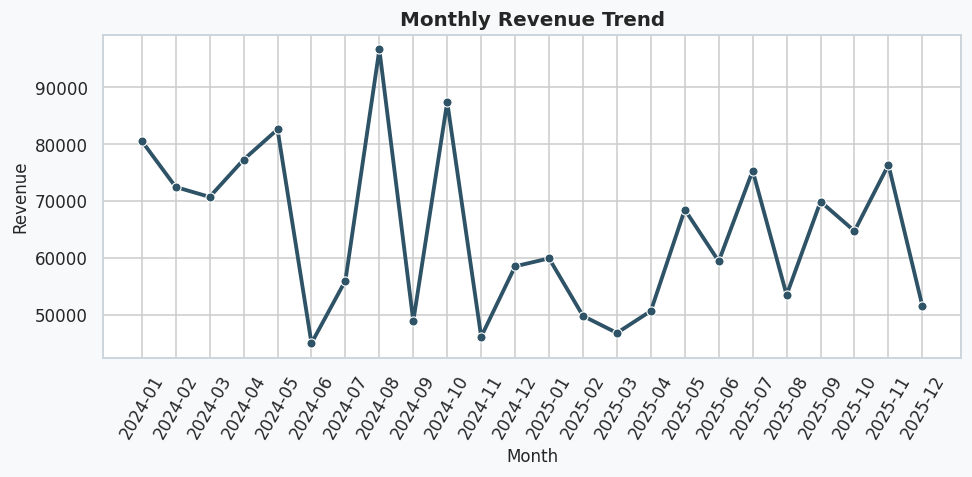

In [19]:
monthly = df.groupby("Month", as_index=False)["Revenue"].sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(data=monthly, x="Month", y="Revenue", marker="o",
              color=PALETTE["primary"], linewidth=2.5, ax=ax)
ax.set_title("Monthly Revenue Trend")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()


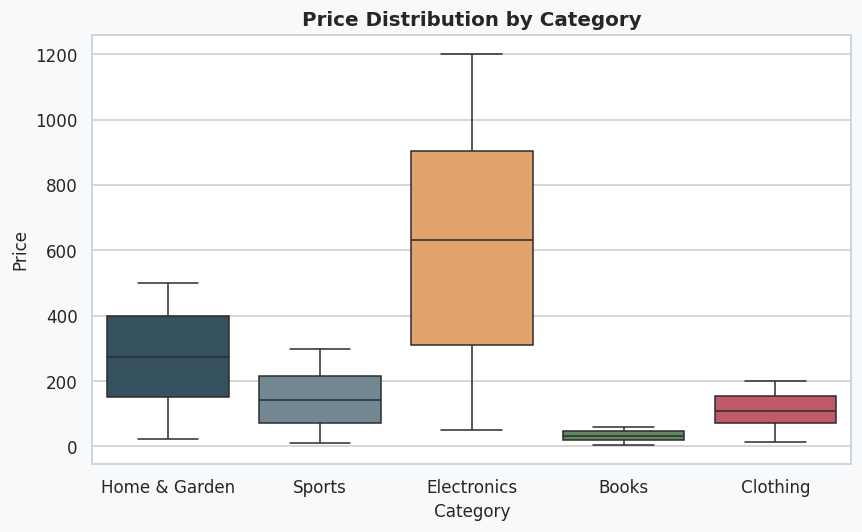

In [20]:
# Quick look at the sample code style: boxplot by category
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='Category', y='Price', data=df, hue='Category',
            palette=CATEGORY_PALETTE, legend=False, ax=ax)
plt.title('Price Distribution by Category')
plt.tight_layout()
plt.show()


## Day 2: Statistical Visualizations

Box plots and violin plots with statistical annotations (medians, means).


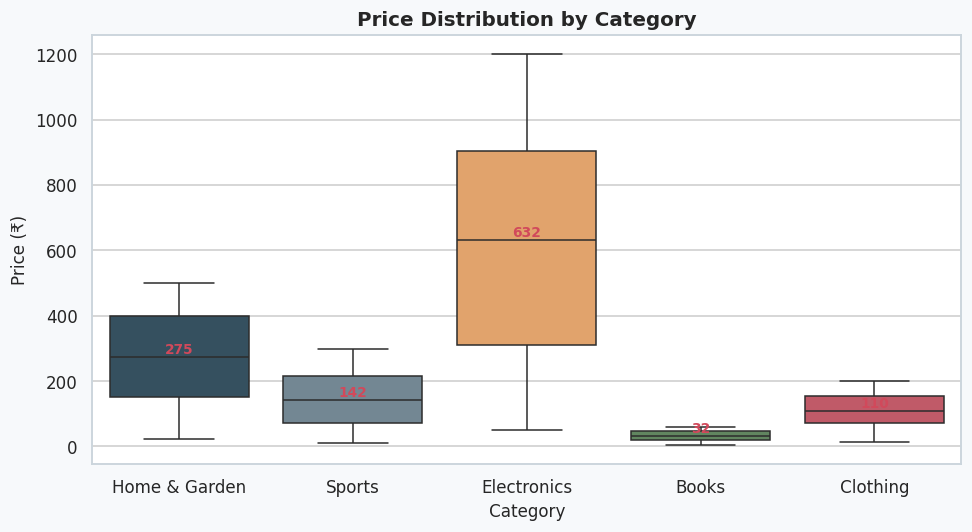

In [21]:
from dashboard_static import plot_price_distribution_box
plot_price_distribution_box(df)
plt.show()


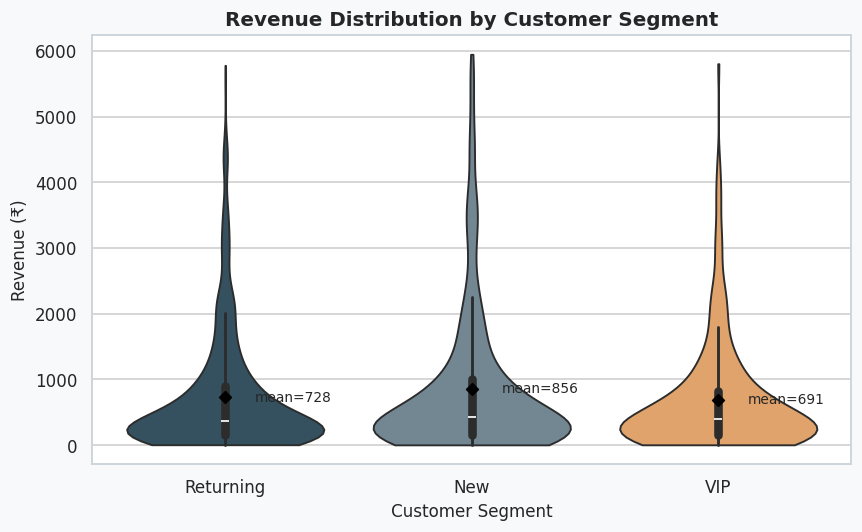

In [22]:
from dashboard_static import plot_revenue_violin_by_segment
plot_revenue_violin_by_segment(df)
plt.show()


## Day 3: Heatmaps & Correlation

A correlation matrix of numeric features and a custom heatmap of
revenue by region and category.


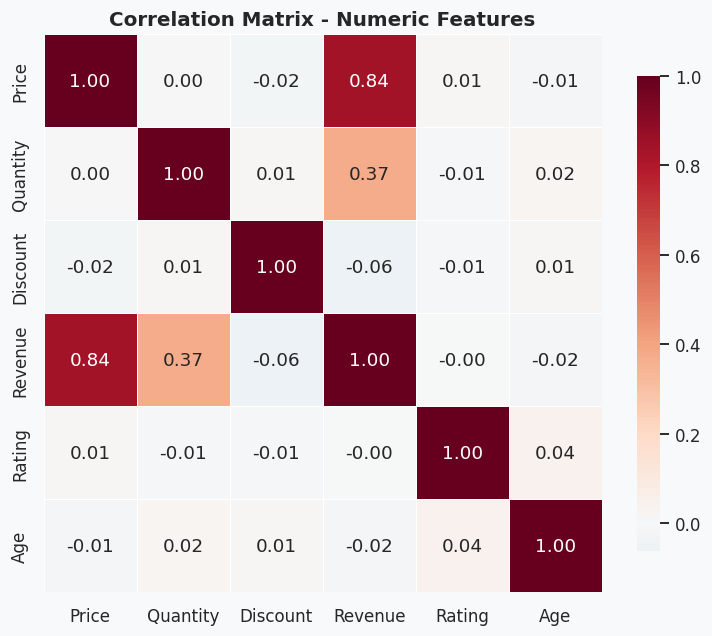

In [23]:
from dashboard_static import plot_correlation_heatmap
plot_correlation_heatmap(df)
plt.show()


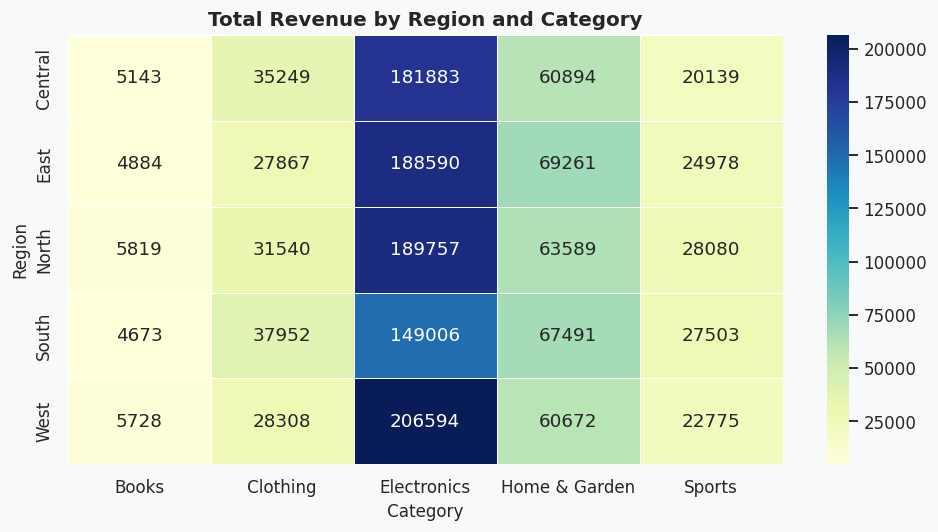

In [24]:
from dashboard_static import plot_region_category_heatmap
plot_region_category_heatmap(df)
plt.show()


## Day 4: Multi-plot Dashboard (2×2 Grid)

A coordinated 2×2 subplot grid combining bar, count, scatter, and
histogram views with a shared color theme.


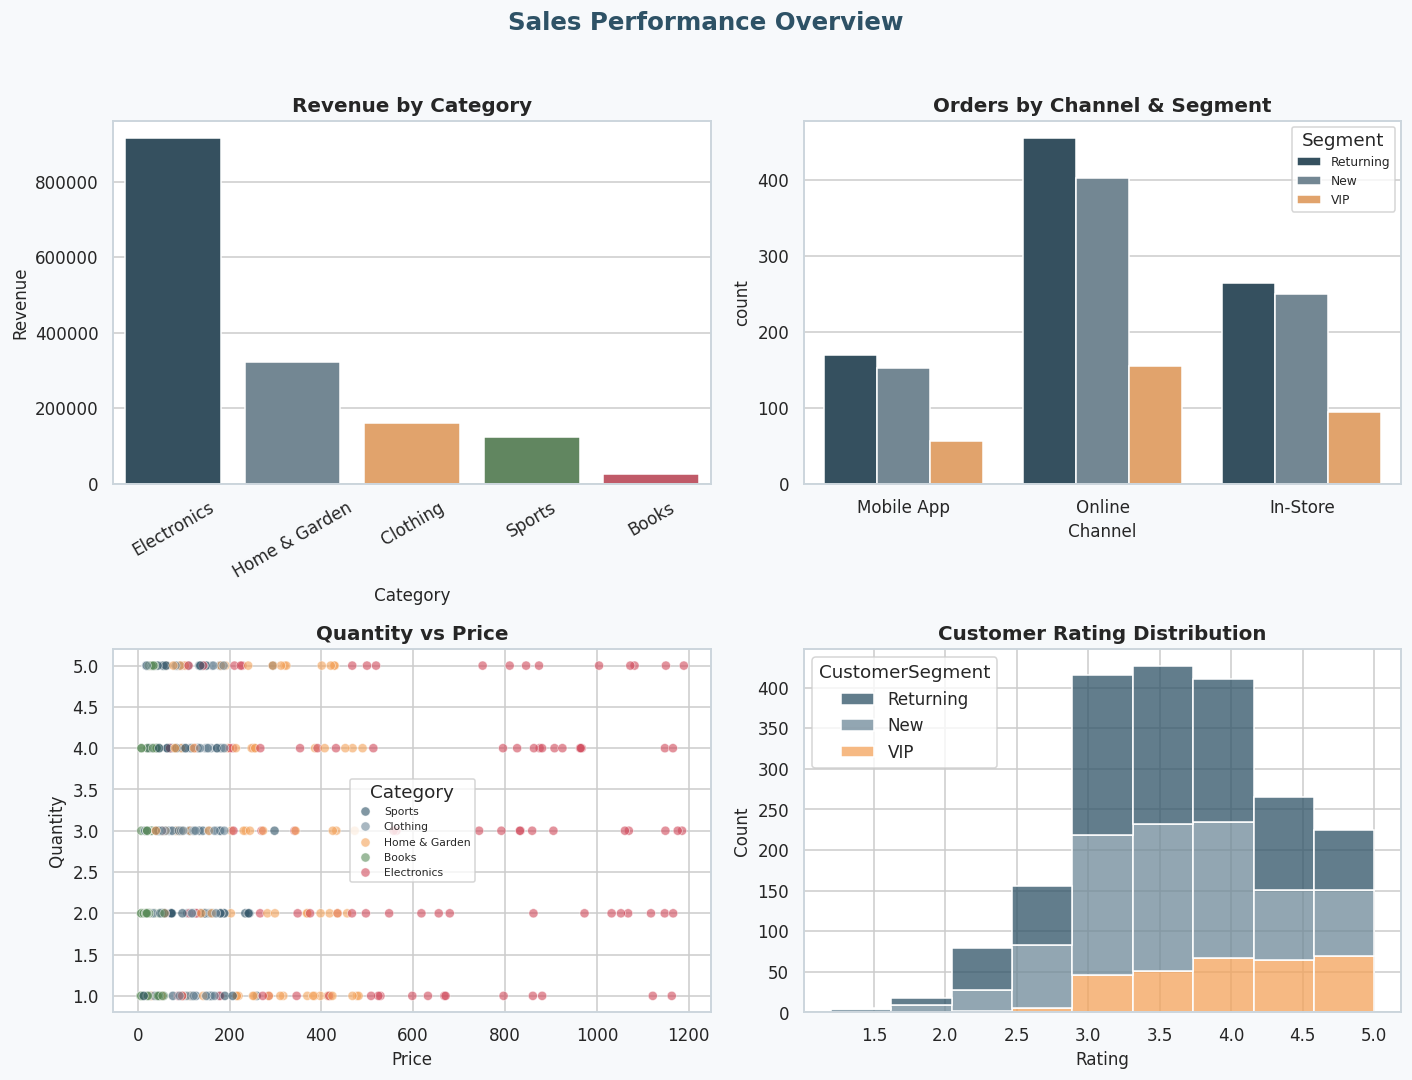

In [25]:
from dashboard_static import plot_2x2_dashboard
plot_2x2_dashboard(df)
plt.show()


## Day 5: Interactive Visualizations (Plotly)

Add hover effects, dropdown menus, and animations.


In [26]:
from dashboard_interactive import interactive_revenue_trend
fig = interactive_revenue_trend(df, save=False)
fig.show()


In [27]:
from dashboard_interactive import animated_quarterly_revenue
fig = animated_quarterly_revenue(df, save=False)
fig.show()


In [28]:
from dashboard_interactive import customer_segmentation_bubble
fig = customer_segmentation_bubble(df, save=False)
fig.show()


In [29]:
from dashboard_interactive import product_performance_sunburst
fig = product_performance_sunburst(df, save=False)
fig.show()


In [31]:
from dashboard_interactive import channel_performance_toggle
fig = channel_performance_toggle(df, save=False)
fig.show()


## Day 6: Dashboard Integration

Combine all visualizations into a single cohesive, branded HTML
dashboard page.


In [32]:
from dashboard_build import build_dashboard
out_path = build_dashboard(df)
print(f"Dashboard saved to: {out_path}")


Dashboard written to c:\Users\srira\Desktop\The developers arena\Week 6 task\dashboard.html
Dashboard saved to: c:\Users\srira\Desktop\The developers arena\Week 6 task\dashboard.html


## Day 7: Polish & Presentation

KPI summary cards and final dashboard preview.
The full interactive dashboard is available in `dashboard.html`
(open it in a browser for the live experience).


In [34]:
kpis = {
    "Total Revenue": f"₹{df['Revenue'].sum():,.0f}",
    "Total Orders": f"{len(df):,}",
    "Avg Order Value": f"₹{df['Revenue'].mean():,.0f}",
    "Avg Rating": f"{df['Rating'].mean():.2f} / 5",
    "Top Category": df.groupby('Category')['Revenue'].sum().idxmax(),
    "Top Region": df.groupby('Region')['Revenue'].sum().idxmax(),
}
for k, v in kpis.items():
    print(f"{k:18s}: {v}")


Total Revenue     : ₹1,548,375
Total Orders      : 2,000
Avg Order Value   : ₹774
Avg Rating        : 3.65 / 5
Top Category      : Electronics
Top Region        : West
